# Notebook 2 — Cleaning Decisions and Feature Plan

This notebook is the **bridge** between exploration and modeling.

Notebook 1 helped me understand the raw data.  
Now I am turning those findings into a clear plan for the final pipeline.

### Goal of this Notebook
- decide which missing values are structural vs true missing values
- review the conservative outlier rule
- decide which numeric columns deserve `log1p`
- separate ordinal, one-hot, and target-encoded columns
- define the engineered features I want in the reusable pipeline
- save the design plan for Notebook 3



##  Imports and setup

In [15]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 200)

DATA_PATH = Path('train.csv')
EDA_PATH = Path('eda_decisions.json')

df = pd.read_csv(DATA_PATH)
if 'Id' in df.columns:
    df = df.drop(columns=['Id'])

eda_decisions = {}

with open(EDA_PATH, 'r') as f:
    eda_decisions = json.load(f)

print('Shape:', df.shape)
print('Target column present:', 'SalePrice' in df.columns)
print('EDA decisions loaded:', bool(eda_decisions))

Shape: (1460, 80)
Target column present: True
EDA decisions loaded: True


## 1. Build a missing-value summary

I want a compact table showing where missingness is concentrated.
That helps me judge whether a column is mostly absent because the feature does not exist, or whether the data is genuinely incomplete.

In [16]:
missing = (
    df.isna().sum()
      .rename('missing_count')
      .to_frame()
      .assign(missing_pct=lambda x: (x['missing_count'] / len(df) * 100).round(2))
      .query('missing_count > 0')
      .sort_values(['missing_count', 'missing_pct'], ascending=False)
)

missing.head(25)

,missing_count,missing_pct
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


### Define structural-missingness groups

Here I write down the columns where missing values are expected by design, such as houses with no pool, no fireplace, or no garage etc

In [17]:
structural_na_cols = {
    'pool_related': ['PoolQC'],
    'misc_feature_related': ['MiscFeature'],
    'alley_access_related': ['Alley'],
    'fence_related': ['Fence'],
    'fireplace_related': ['FireplaceQu'],
    'garage_related': ['GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond'],
    'basement_related': ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2'],
    'masonry_related': ['MasVnrType', 'MasVnrArea'],
}

structural_na_flat = sorted({c for cols in structural_na_cols.values() for c in cols if c in df.columns})
true_na_candidates = [c for c in missing.index if c not in structural_na_flat]

structural_summary = pd.DataFrame({
    'column': missing.index,
    'missing_count': missing['missing_count'].values,
    'missing_pct': missing['missing_pct'].values,
    'na_type': ['Structural based' if c in structural_na_flat else 'Likely true or data-quality NA'
                for c in missing.index]
})

structural_summary

,column,missing_count,missing_pct,na_type
0,PoolQC,1453,99.52,Structural based
1,MiscFeature,1406,96.30,Structural based
2,Alley,1369,93.77,Structural based
3,Fence,1179,80.75,Structural based
4,MasVnrType,872,59.73,Structural based
5,FireplaceQu,690,47.26,Structural based
6,LotFrontage,259,17.74,Likely true or data-quality NA
7,GarageType,81,5.55,Structural based
8,GarageYrBlt,81,5.55,Structural based
9,GarageFinish,81,5.55,Structural based


### Turn the NA logic into a practical fill plan

Instead of leaving the idea abstract, I convert it into an explicit table:
which columns are structural, which are true missing, and what fill rule each group should get.

In [18]:
na_plan = []

for group, cols in structural_na_cols.items():
    for col in cols:
        if col not in df.columns:
            continue
        if pd.api.types.is_numeric_dtype(df[col]):
            fill_rule = 'Structural numeric -> fill 0'
        else:
            fill_rule = 'Structural categorical -> fill "None"'
        na_plan.append((col, 'structural', fill_rule))

for col in true_na_candidates:
    if pd.api.types.is_numeric_dtype(df[col]):
        fill_rule = 'True numeric NA -> median'
    else:
        fill_rule = 'True categorical NA -> mode'
    na_plan.append((col, 'true', fill_rule))

na_plan_df = pd.DataFrame(na_plan, columns=['column', 'na_kind', 'planned_fill'])
na_plan_df.sort_values(['na_kind', 'column']).head(40)

,column,na_kind,planned_fill
2,Alley,structural,"Structural categorical -> fill ""None"""
11,BsmtCond,structural,"Structural categorical -> fill ""None"""
12,BsmtExposure,structural,"Structural categorical -> fill ""None"""
13,BsmtFinType1,structural,"Structural categorical -> fill ""None"""
14,BsmtFinType2,structural,"Structural categorical -> fill ""None"""
10,BsmtQual,structural,"Structural categorical -> fill ""None"""
3,Fence,structural,"Structural categorical -> fill ""None"""
4,FireplaceQu,structural,"Structural categorical -> fill ""None"""
9,GarageCond,structural,"Structural categorical -> fill ""None"""
7,GarageFinish,structural,"Structural categorical -> fill ""None"""


### Decision after the NA plan

The key takeaway is simple:
- structural missing values should preserve meaning, usually with `'None'` or `0`
- true missing values need regular imputation such as median or mode

That is much better than a one-size-fits-all fill rule.

## Revisit the key outlier pattern

I do not want aggressive outlier deletion.
I only want to check the specific large-house / low-price pattern that is widely discussed in Ames.

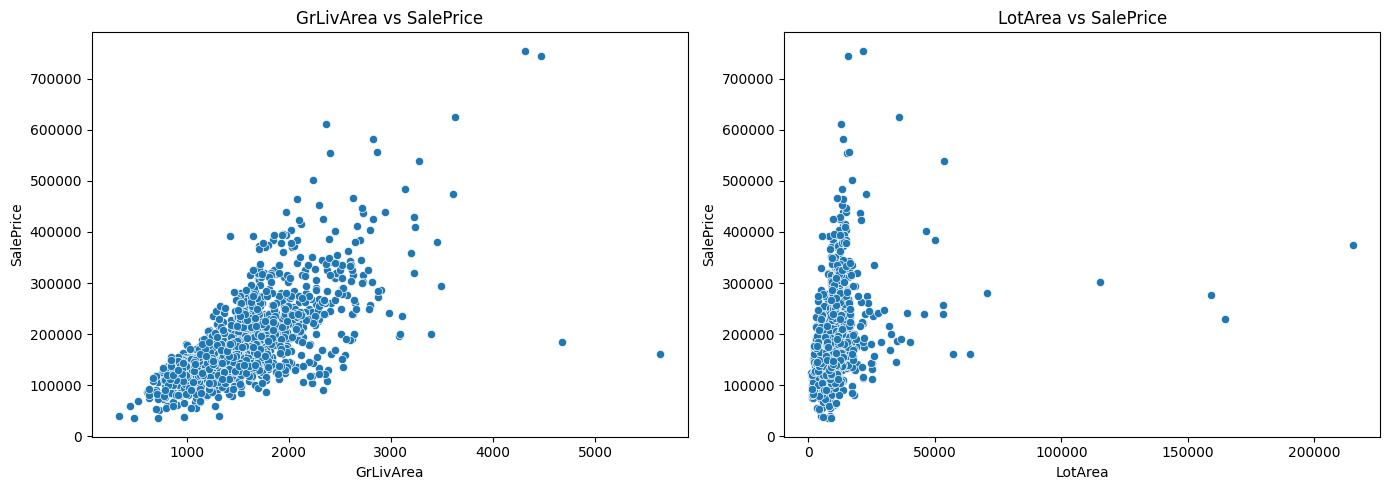

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x='GrLivArea', y='SalePrice', ax=axes[0], s=35)
axes[0].set_title('GrLivArea vs SalePrice')

sns.scatterplot(data=df, x='LotArea', y='SalePrice', ax=axes[1], s=35)
axes[1].set_title('LotArea vs SalePrice')

plt.tight_layout()
plt.show()

### Create the conservative outlier flag

Now I formalize the outlier rule instead of keeping it vague.
This makes the later modeling step reproducible.

In [20]:
outlier_mask = (df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)

print('Rows flagged by conservative outlier rule:', int(outlier_mask.sum()))
df.loc[outlier_mask, ['GrLivArea', 'SalePrice']].sort_values('GrLivArea', ascending=False)

Rows flagged by conservative outlier rule: 2


,GrLivArea,SalePrice
1298,5642,160000
523,4676,184750


### Apply the outlier rule once and keep the cleaned modeling frame

This gives me the dataset version I want to reason about for the rest of the notebook.

In [21]:
df_model = df.loc[~outlier_mask].copy()

print('Original shape :', df.shape)
print('After outliers :', df_model.shape)

Original shape : (1460, 80)
After outliers : (1458, 80)


### Decision after the outlier step

I am using a conservative outlier treatment.
That keeps the workflow believable and avoids deleting too much data 

## 3. Find numeric columns that are still strongly skewed

After removing the few flagged outliers, I check numeric skewness again.
The goal is not to transform everything — only the columns where `log1p` is still justified.

In [22]:
num_cols = df_model.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != 'SalePrice']

skew_df = (
    df_model[num_cols]
      .skew(numeric_only=True)
      .rename('skewness')
      .to_frame()
      .sort_values('skewness', ascending=False)
)

skew_df.head(20)

,skewness
MiscVal,24.460085
PoolArea,15.948945
LotArea,12.573925
3SsnPorch,10.297106
LowQualFinSF,9.004955
KitchenAbvGr,4.484883
BsmtFinSF2,4.251925
ScreenPorch,4.118929
BsmtHalfBath,4.100114
EnclosedPorch,3.087164


### Filter the skewed columns into realistic log-transform candidates

I exclude year-like and count-like variables because logging those usually makes less sense.
This leaves me with a more defensible list.

In [23]:
candidate_log_cols = skew_df.query('skewness > 0.75').index.tolist()

year_like = {'YearBuilt', 'YearRemodAdd', 'GarageYrBlt', 'YrSold', 'MoSold'}
count_like = {'OverallQual', 'OverallCond', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
              'FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath', 'Fireplaces',
              'GarageCars', 'PoolArea', 'MiscVal'}

log_transform_cols = [c for c in candidate_log_cols if c not in year_like and c not in count_like]

pd.DataFrame({
    'log_transform_candidate': log_transform_cols,
    'skewness': [round(float(skew_df.loc[c, 'skewness']), 3) for c in log_transform_cols]
}).head(30)

,log_transform_candidate,skewness
0,LotArea,12.574
1,3SsnPorch,10.297
2,LowQualFinSF,9.005
3,BsmtFinSF2,4.252
4,ScreenPorch,4.119
5,EnclosedPorch,3.087
6,MasVnrArea,2.688
7,OpenPorchSF,2.340
8,WoodDeckSF,1.546
9,LotFrontage,1.543


### Decision after the skewness review

I will keep the target log transform and apply `log1p` only to a selected set of skewed predictors.
This is a more thoughtful choice than logging every positive numeric column.

## 4. Plan the encoding strategy

Now I move to the categorical side.
I want to separate columns into ordinal, one-hot, and target-encoding groups instead of using one generic rule for all text columns.

In [24]:
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
cardinality = pd.DataFrame({
    'column': cat_cols,
    'n_unique': [df_model[c].nunique(dropna=True) for c in cat_cols]
}).sort_values(['n_unique', 'column'], ascending=[False, True])

cardinality.head(30)

,column,n_unique
8,Neighborhood,25
16,Exterior2nd,16
15,Exterior1st,15
9,Condition1,9
41,SaleType,9
10,Condition2,8
12,HouseStyle,8
31,Functional,7
14,RoofMatl,7
24,BsmtFinType1,6


### Write down the ordinal columns explicitly

These columns have a natural order, so I should map them rather than one-hot encode them.

In [25]:
ordinal_cols = [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 'KitchenQual',
    'FireplaceQu', 'GarageQual', 'GarageCond', 'GarageFinish', 'BsmtExposure',
    'BsmtFinType1', 'BsmtFinType2', 'Functional', 'Fence', 'PoolQC', 'LandSlope',
    'LotShape', 'PavedDrive', 'Utilities'
]
ordinal_cols = [c for c in ordinal_cols if c in df_model.columns]

target_encode_cols = [c for c in ['Neighborhood', 'Exterior1st', 'Exterior2nd'] if c in df_model.columns]

onehot_cols = [c for c in cat_cols if c not in ordinal_cols and c not in target_encode_cols]

encoding_plan = pd.DataFrame({
    'column': ordinal_cols + target_encode_cols + onehot_cols,
    'encoding_strategy': (
        ['ordinal_mapping'] * len(ordinal_cols) +
        ['target_encoding'] * len(target_encode_cols) +
        ['one_hot'] * len(onehot_cols)
    )
}).sort_values(['encoding_strategy', 'column'])

encoding_plan.head(80)

,column,encoding_strategy
25,Alley,one_hot
30,BldgType,one_hot
37,CentralAir,one_hot
28,Condition1,one_hot
29,Condition2,one_hot
38,Electrical,one_hot
35,Foundation,one_hot
39,GarageType,one_hot
36,Heating,one_hot
31,HouseStyle,one_hot


### Decision after the encoding review

- ordinal mapping for ordered quality/condition features
- one-hot encoding for smaller nominal categories
- target encoding for a small set of high-impact nominal features


## 5. Define the engineered feature plan

I want the important engineered features to live in one reusable place, not be manually recreated in different notebooks or inside the app.

In [26]:
engineered_features = [
    'HouseAge',
    'RemodAge',
    'IsRemodeled',
    'TotalSF',
    'TotalPorchSF',
    'TotalBaths',
    'QualArea',
    'OverallScore',
    'QualCondScore',
    'LiveAreaPerRoom',
    'FinishedBsmtRatio',
    'TotalOutdoorSF',
    'GarageScore',
    'BathsPerBedroom',
    'Has2ndFloor',
    'HasGarage',
    'HasBasement',
]

pd.DataFrame({'engineered_feature': engineered_features})

,engineered_feature
0,HouseAge
1,RemodAge
2,IsRemodeled
3,TotalSF
4,TotalPorchSF
5,TotalBaths
6,QualArea
7,OverallScore
8,QualCondScore
9,LiveAreaPerRoom


## 6. Add a couple of compact visuals for presentation value

This notebook is mainly about decisions, but a couple of clean visuals help show that the decisions are data-driven and not arbitrary.

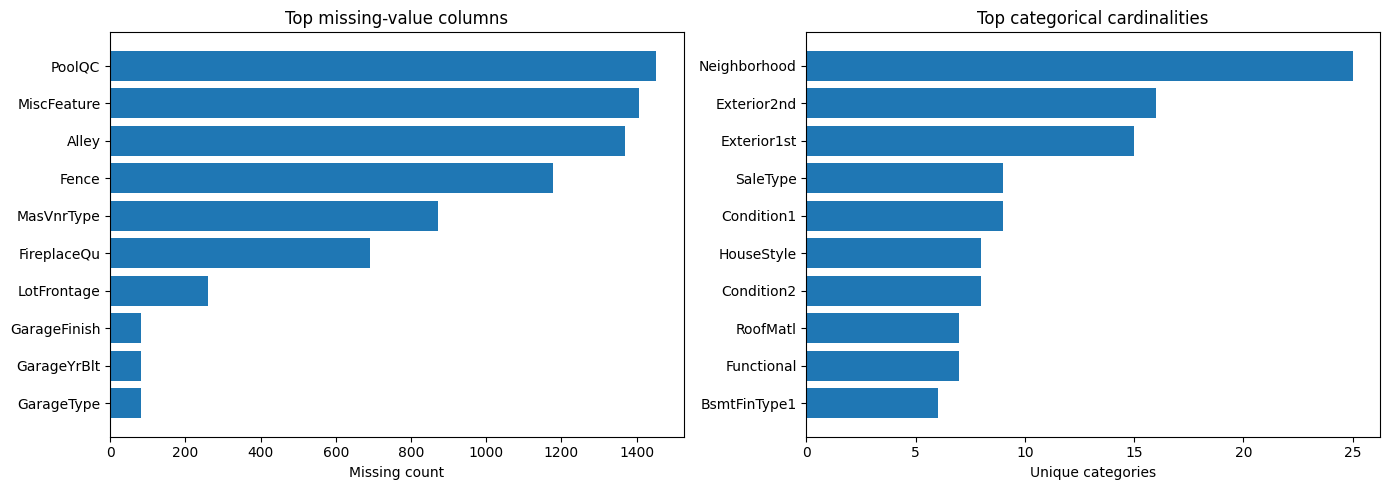

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_missing = missing.head(10).sort_values('missing_count')
axes[0].barh(top_missing.index, top_missing['missing_count'])
axes[0].set_title('Top missing-value columns')
axes[0].set_xlabel('Missing count')

top_card = cardinality.head(10).sort_values('n_unique')
axes[1].barh(top_card['column'], top_card['n_unique'])
axes[1].set_title('Top categorical cardinalities')
axes[1].set_xlabel('Unique categories')

plt.tight_layout()
plt.show()

## 7. Save the design artifact for Notebook 3

Now I package the cleaning and feature-design decisions so the modeling notebook can reuse them consistently without rewriting the logic.

In [28]:
feature_design_plan = {
    'rows_before_outlier_removal': int(df.shape[0]),
    'rows_after_outlier_removal': int(df_model.shape[0]),
    'outlier_rule': {
        'description': 'Remove extreme GrLivArea rows with comparatively low sale price',
        'rule': '(GrLivArea > 4000) & (SalePrice < 300000)',
        'rows_removed': int(outlier_mask.sum()),
    },
    'structural_na_groups': structural_na_cols,
    'true_na_candidates': true_na_candidates,
    'log_transform_cols': log_transform_cols,
    'ordinal_cols': ordinal_cols,
    'target_encode_cols': target_encode_cols,
    'onehot_cols': onehot_cols,
    'engineered_features': engineered_features,
}

with open('feature_design_plan.json', 'w') as f:
    json.dump(feature_design_plan, f, indent=2)

print('Saved feature_design_plan.json')
print('Target-encoded columns:', target_encode_cols)
print('Log-transform columns:', len(log_transform_cols))

Saved feature_design_plan.json
Target-encoded columns: ['Neighborhood', 'Exterior1st', 'Exterior2nd']
Log-transform columns: 16
